|<div style="width:330px"><img src="https://www.ufz.de/static/custom/weblayout/DefaultInternetLayout/img/logos/ufz_transparent_de_blue.png" width="300"/></div>|<div style="width:290px"><img src="https://discourse.opengeosys.org/uploads/default/original/1X/a288c27cc8f73e6830ad98b8729637a260ce3490.png" width="290"/></div>|<div style="width:330px"><img src="https://github.com/nagelt/Teaching_Scripts/raw/9d9e29ecca4b04eaf7397938eacbf116d37ddc93/Images/TUBAF_Logo_blau.png" width="300"/></div>|
|---|---|--:|

Dr. Mehran Ghasabeh,
\
Prof. Dr. Thomas Nagel

*Chair of Soil Mechanics and Foundation Engineering  
Geotechnical Institute  
Technische Universität Bergakademie Freiberg*

https://tu-freiberg.de/en/soilmechanics

# Hydro-Mechanically Coupled Processes in Fault-Controlled Deep Aquifers

## Benchmarking the embedded fracture model against lower-dimensional interface elements

### 1. Introduction
This benchmark supports the development of a three-dimensional OpenGeoSys reservoir model for investigating hydro-mechanical processes in fault-controlled deep aquifers. It focuses on the two-way interaction between fluid flow and fracture deformation: changes in pore pressure alter effective stress and may open or close fractures, while changes in hydraulic aperture affect permeability and flow [1]. This interaction is relevant to the Geretsried geothermal site, where the first deep well reached the hot Upper Jurassic (Malm) carbonate reservoir but delivered substantially lower productivity than anticipated. The hydraulic behaviour of the fault and fracture network, including its response to stimulation, is therefore central to assessing the feasibility of geothermal exploitation [7]. Building on Walter’s three-dimensional OpenGeoSys model of pressure-dependent fracture deformation during borehole tests, the present benchmark uses idealized porous-media domains with one or two fractures to compare how the Lower-dimensional Interface Element (LIE) and Embedded Fracture Permeability (EFP) formulations represent coupled hydro-mechanical processes.

In [1]:
import math
import ogstools as ot
import vtuIO
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from tqdm import tqdm

# --- Unified course plotting style (identical in all three course notebooks) ---
# Color identifies the entity (model, monitoring point, angle, time);
# linestyle identifies the solution type: simulation = solid (or markers
# for sampled points), analytical/reference = dashed (black if unambiguous).
# Continuous fields use the perceptually uniform "viridis" colormap.
OKABE_ITO = ["#0072B2", "#E69F00", "#009E73", "#D55E00",
             "#CC79A7", "#56B4E9", "#F0E442", "#000000"]
CMAP_FIELD = "viridis"
plt.rcParams.update({
    "font.size": 13,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.5,
    "legend.frameon": False,
    "axes.prop_cycle": plt.cycler(color=OKABE_ITO),
})

# Fixed model colors used throughout this notebook.
C_LIE, C_EFP = OKABE_ITO[0], OKABE_ITO[1]

## 2. Mesh generation with the Gmsh Python API

The four meshes are generated directly from Python, following the same linear-Gmsh to quadratic-OGS workflow as the tunnel example.

In [2]:
import gmsh
from mesh_lie_efpm import MeshGenerator

def generate_benchmark_mesh(approach, number_of_fractures):
    """Generate one benchmark mesh using the unified MeshGenerator."""
    model_name = f"{approach}_{number_of_fractures}_fracture"
    gmsh.initialize(readConfigFiles=False)
    try:
        gmsh.model.add(model_name)
        mesh_generator = MeshGenerator(
            gmsh_model=gmsh.model,
            approach=approach,
            number_of_fractures=number_of_fractures,
        )
        return mesh_generator.generate_meshes(order=2)
    finally:
        gmsh.finalize()


mesh_files = {
    "single_LIE": generate_benchmark_mesh("LIE", 1),
    "single_EFPM": generate_benchmark_mesh("EFPM", 1),
    "double_EFPM": generate_benchmark_mesh("EFPM", 2),
}

for name, mesh_file in mesh_files.items():
    print(f"{name}: {mesh_file}")

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 50%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 80%] Meshing curve 6 (Line)
Info    : [ 90%] Meshing curve 7 (Line)
Info    : Done meshing 1D (Wall 0.000595286s, CPU 0s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 60%] Meshing surface 2 (Transfinite)
Info    : Done meshing 2D (Wall 0.000199893s, CPU 0.002271s)
Info    : 1365 nodes 1476 elements
Info    : Writing 'SingleFractureMedium/LIE/domain.msh'...
Info    : Done writing 'SingleFractureMedium/LIE/domain.msh'
info: Reading SingleFractureMedium/LIE/domain.msh.
info: 	... finished.
info: Nr. Nodes: 1365.
info: Nr. Elements: 1326.
info: Mem for mesh: 0 MiB
info: Time for reading: 0.002711 seconds.
info: Read 1365 nodes and 1326 elements.
info: Please check your mesh carefully!
info: Degenerated or redundant mes

### 2.1 Single-Fracture Porous Medium

In [3]:
# Generate the OGS project files directly from Python (ogstools.Project),
# analogous to the mesh generation above:
from prj_lie_efpm import ProjectGenerator

prj_single_lie = ProjectGenerator("LIE", number_of_fractures=1).generate_project()
prj_single_efp = ProjectGenerator("EFPM", number_of_fractures=1).generate_project()

model_lie = ot.Project(input_file=prj_single_lie, output_file=prj_single_lie)
model_efp = ot.Project(input_file=prj_single_efp, output_file=prj_single_efp)
model_list = (model_lie, model_efp)

### 2.2 Double-Fracture Porous Medium

In [4]:
# Double fracture: EFP model only. Official OpenGeoSys supports a single
# displacement jump in HYDRO_MECHANICS_WITH_LIE, so there is no LIE variant
# for two fractures.
prj_double_efp = ProjectGenerator("EFPM", number_of_fractures=2).generate_project()

model_efp_DF = ot.Project(input_file=prj_double_efp, output_file=prj_double_efp)
model_list_DF = (model_efp_DF,)

The following benchmark tests validate the Embedded Fracture Permeability (EFP) model [1] against the Lower-dimensional Interface Element (LIE) approach [2] for single- and double-fracture porous media.
The LIE approach represents fractures as zero-thickness elements by embedding them within a continuous elemens mesh. The model was previously validated against a semi-analytical somution in [3]. 
Furthermore, the LIE modelling approach was applied by Cacae et al. in 2013 [4] to simulate fracture-dominated flow in the Traunreuth deep geothermal project. Consequently, it serves as a suitable reference model for confirming the applicability of the EFP approach to fracture-dominated reservoir systems.

In order to create a conclusive benchmark, a simple hydro-mechanical (HM) coupled problem of a pre-existing 2D single fracture is chosen. The fracture is located symmetrically within a $\Delta\text{y}=1\,\text{m}$ wide rock matrix and has a horizontal extension of $\Delta\text{x}=12.5 \,\text{m}$, as to be seen in Fig.1.


<center>
<figure>
      <img src="img/01_Benchmark.jpg" alt="Benchmark" style="width:80%">
      <figcaption style="line-height:1.5;width:80%" >  
        Fig.1: Schematic geometries for fluid flow through a single fracture being conducted in the LIE and the EFP model. (Adapted from [3])
     </figcaption>
</center>
</figure>


## 3. Parametrisation

### 3.1 Permeability approach

Comparing the EFP to the LIE model in Fig.1.,  the relationship of $s \gg b $ applies for the thickness of the embedded fracture zone $s$. That is because it is inconvenient to mesh tiny finite elements with an element side length of $b$.
Therefore, in order to achieve a similar pressure response within both models, an equivalent transmissibility $T$ is applied. It means that the isotropic permeability $k$ is integrated over the thickness of the homogeneous reservoir normal to the flow direction to ensure an equal mass flow $\dot m^f=\text{const.}$.

In general, both models apply the cubic law for the fracture permeability

$$
k_\text{F}=\frac{b^2}{12}
$$

Being applied at the LIE model, $T_\text{LIE}$ reads as

$$
T_\text{LIE}=k_\text{F} \, b = \frac{b^2}{12}\, b
$$

In comparison, the equivalent continuum approach in Fig.2. illustrtates, how the transmissibility $T$ derives for the EFP model in $x$-direction from

$$
  T_\text{EFP} = k \, s \qquad  \text{with} \qquad k = k_\text{M}+\frac{b}{a}\,k_\text{F}
$$

<center>
<figure>
      <img src="img/02_embedded_fracs.jpg" alt="Benchmark" style="width:80%">
       <figcaption style="line-height:1.5;width:70%" >  
        Fig.2.: In EFP model, a finite matrix element with a set of embedded fractures is parametrized by the element thickness <i>s</i> in normal direction <i>y</i> of the fault plane and a continuous spacing <i>a</i>. The fracture aperture is determined by <i>b</i>. (Adapted from [5])
     </figcaption>
</figure>
</center>

The total permeability $k$ of the embedded fracture zone consists of the intrinsic matrix permeability $k_\text{M}$, the ratio of $b$ and the mean fracture distance $a$ as well as the fracture permeability $k_\text{F}$. $k_\text{M}$ is assumed to be nearly impermeable for the current benchmark example. In additon, there applies $s=a$ due to the existance of only one fracture in the benchmark. The formulation of $T_\text{EFP}$ simplifies therefore to
$$
T_\text{EFP}=\frac{b^2}{12}\,b
$$


The comparison reveals that the initial apertures $b_\text{0}$ of LIE and EFP must be equal. While the initial aperture $b_\text{0}$ is a direct input parameter in LIE, $b_\text{0}$ is chosen to be applied in the EFP via the threshold strain $\epsilon_\text{0}$ regarding the relationship

$$
b(t=0)=b_\text{0} + a \, \langle \epsilon_\text{n}-\epsilon_\text{0} \rangle
$$
The normal strain $\epsilon_\text{n}$ and the initial aperture $b_\text{0}$ are assumed to be zero at the initial stage. Hence, the aperture at the initial stage is implemented as

$$
\epsilon_\text{0}= -\frac{b(t=0)}{a}
$$

The respective parameters are defined and implemented as follows:

In [5]:
k_m = 1e-21  # intrinsic permeability
b = 1e-5  # aperture at t=0
b0 = 0  # initial aperture
a = 1e-3  # Mean fracture distance
e0 = -b / a  # Threshold strain

# Applying parameters
# LIE
model_lie.replace_parameter_value(name="k", value=k_m)
model_lie.replace_parameter_value(name="b", value=b)
# EFP
model_efp.replace_text(
    "%.2e" % (b0**2 / 12),
    xpath="./media/medium/properties/property[name='permeability']/intrinsic_permeability",
)
model_efp.replace_text(
    "%.2e" % a,
    xpath="./media/medium/properties/property[name='permeability']/mean_frac_distance",
)
model_efp.replace_text(
    "%.2e" % e0,
    xpath="./media/medium/properties/property[name='permeability']/threshold_strain",
)
# EFP
model_efp_DF.replace_text(
    "%.2e" % (b0**2 / 12),
    xpath="./media/medium/properties/property[name='permeability']/intrinsic_permeability",
)
model_efp_DF.replace_text(
    "%.2e" % a,
    xpath="./media/medium/properties/property[name='permeability']/mean_frac_distance",
)
model_efp_DF.replace_text(
    "%.2e" % e0,
    xpath="./media/medium/properties/property[name='permeability']/threshold_strain",
)

print(" b=  %.2e for t=0 \n a=  %.2e \n e0=%.2e   " % (b, a, e0))

model_efp_DF.write_input()

 b=  1.00e-05 for t=0 
 a=  1.00e-03 
 e0=-1.00e-02   


### 3.2 Storage and Compressibility

In the EFP modelling approach, the storage term is calculated via the input parameters fluid compressibility $\kappa^\mathrm{f}_\text{R}$ and the real compressibility of the solid $\kappa^\mathrm{s}_\text{R}$. <br>
$\kappa^\mathrm{f}_\text{R}$ is implemented via the pressure dependent fluid density

$$
\rho^\mathrm{f}_\text{R} (p^\mathrm{f})= \rho^\mathrm{f}_\text{ref} \left ( 1 +  \kappa^\mathrm{f}_\text{R} \left (  p^\mathrm{f}_\text{R} - p^\mathrm{f}_\text{ref} \right ) \right )
$$


Furthermore, $\kappa^\mathrm{s}_\text{R}$ is calculated via the Biot-Willis coefficient $\alpha_\text{B}$, the drained bulk modulus of the grain skeleton $K^\mathrm{s}$, Young's modulus of the matrix $E_\text{M}$ and Poisson's ratio $\nu$ 

$$
\kappa^\mathrm{s}_\text{R} = \frac{1-\alpha_\text{B}}{K^\mathrm{s}}  \qquad \text{where} \qquad K^\mathrm{s} = \frac{E_\text{M}}{3 \, (1-2\,\nu)} \qquad \text{applies.}
$$

On the other hand, the LIE model uses the specific storage $S_\text{s}$ as input parameter which is calculated from 

$$
S_\text{s} = \left (  \left (  \alpha_\text{B} - \phi  \right ) \, \kappa^\mathrm{s}_\text{R} + \phi \, \kappa^\mathrm{f}_\text{R} \right )
$$

where $\phi$ is the porosity of the porous medium. The fluid viscosity $\mu^\mathrm{f}$ is implemented as a constant parameter in both models,.

<br>

### 3.3 Equivalent joint normal stiffness

The LIE model uses the joint normal stiffness $K_\text{n}$ and the joint shear stiffness $K_\text{s}$ as elastic parameters for dertermining the mechanical fracture behaviour. For the EFP, $K_\text{n}$ is implemented via an equivalent Young's modulus $E_\text{RM}$ for the embedded fracture zone as being derived by Gerrard [6]:

$$
 \frac{1}{E_\text{RM}}=\frac{1}{E_\text{M}}+\frac{1}{K_\text{n}\,a}
$$

The joint shear stiffness $K_\text{s}$ is not considered in the present benchmark.

In [6]:
###
### Material Parametrisation
###

# Fluid
rho_fr = 1e3
kappa_fr = 1e-7
mu_f = 1e-3  # Pa s

# Solid parameters
rho_sr = 2.716e3  # kg/m³
a_b = 1  # Biot-Willis
E = 60e9
nu = 0
poro_matrix = 0.001

# Fracture properties
poro_frac = poro_matrix  # 1e-5
Kn = 1e11
Ks = 1e11

###
### Calculation
###

# Calc Storage Porous Medium LIE:
K_S = E / (3 * (1 - 2 * nu))
kappa_sr = (1.0 - a_b) / K_S
S_matrix = (a_b - poro_matrix) * kappa_sr + poro_matrix * kappa_fr

# Calc Storage Fracture LIE
S_f = (a_b - poro_frac) * kappa_sr + poro_frac * kappa_fr

# Calc Equiv. Young's Modulus EFP
E_rm = (1 / E + 1 / a / Kn) ** (-1)

print(
    "\
kappa_sr = %f \n\
S_matrix = %.2e \n\
     S_f = %.2e \n\
    E_rm = %.2e"
    % (kappa_sr, S_matrix, S_f, E_rm)
)

###
### Applying Parameters
###

# Replace Parameters in LIE
model_lie.replace_parameter_value(name="rho_fr", value=rho_fr)
model_lie.replace_parameter_value(name="mu", value=mu_f)
model_lie.replace_parameter_value(name="rho_sr", value=rho_sr)
model_lie.replace_parameter_value(name="phi", value=poro_matrix)
model_lie.replace_parameter_value(name="biot_m", value=a_b)
model_lie.replace_parameter_value(name="E", value="%.2e" % E)
model_lie.replace_parameter_value(name="nu", value=nu)
model_lie.replace_parameter_value(name="S", value="%.2e" % S_matrix)
# Fracture
model_lie.replace_parameter_value(name="S_f", value="%.2e" % S_f)
model_lie.replace_parameter_value(name="biot_f", value=a_b)
model_lie.replace_parameter_value(name="Kn", value="%.2e" % Kn)
model_lie.replace_parameter_value(name="Ks", value="%.2e" % Ks)

# Replace Parameters in EFP
model_efp.replace_text(
    rho_fr,
    xpath="./media/medium/phases/phase[type='Gas']/properties/property[name='density']/reference_value",
)
model_efp.replace_text(
    kappa_fr,
    xpath=(
        "./media/medium/phases/phase[type='Gas']/properties/property[name='density']/independent_variable/slope"
    ),
)
#
model_efp_DF.replace_text(
    rho_fr,
    xpath="./media/medium/phases/phase[type='Gas']/properties/property[name='density']/reference_value",
)
model_efp_DF.replace_text(
    kappa_fr,
    xpath=(
        "./media/medium/phases/phase[type='Gas']/properties/property[name='density']/independent_variable/slope"
    ),
)

for id in (0, 1):
    model_efp.replace_phase_property_value(
        mediumid=id, phase="Gas", name="viscosity", value=mu_f
    )
    model_efp.replace_phase_property_value(
        mediumid=id, phase="Solid", name="density", value=rho_sr
    )
    model_efp.replace_medium_property_value(
        mediumid=id, name="biot_coefficient", value=a_b
    )
#
model_efp_DF.replace_phase_property_value(
    mediumid=0, phase="Gas", name="viscosity", value=mu_f
)
model_efp_DF.replace_phase_property_value(
    mediumid=0, phase="Solid", name="density", value=rho_sr
)
model_efp_DF.replace_medium_property_value(
    mediumid=0, name="biot_coefficient", value=a_b
)
#
model_efp_DF.replace_phase_property_value(
    mediumid="1,2", phase="Gas", name="viscosity", value=mu_f
)
model_efp_DF.replace_phase_property_value(
    mediumid="1,2", phase="Solid", name="density", value=rho_sr
)
model_efp_DF.replace_medium_property_value(
    mediumid="1,2", name="biot_coefficient", value=a_b
)
#
model_efp.replace_medium_property_value(mediumid=0, name="porosity", value=poro_matrix)
model_efp.replace_medium_property_value(mediumid=1, name="porosity", value=poro_frac)
model_efp.replace_text(
    "%.2e" % E, xpath="./parameters/parameter[name='E']/index_values[index='0']/value"
)
model_efp.replace_text(
    "%.2e" % E_rm, xpath="./parameters/parameter[name='E']/index_values[index='1']/value"
)
model_efp.replace_parameter_value(name="nu", value=nu)
#
model_efp_DF.replace_medium_property_value(
    mediumid=0, name="porosity", value=poro_matrix
)
model_efp_DF.replace_medium_property_value(
    mediumid="1,2", name="porosity", value=poro_frac
)
model_efp_DF.replace_text(
    "%.2e" % E, xpath="./parameters/parameter[name='E']/index_values[index='0']/value"
)
model_efp_DF.replace_text(
    "%.2e" % E_rm, xpath="./parameters/parameter[name='E']/index_values[index='1']/value"
)
model_efp_DF.replace_parameter_value(name="nu", value=nu)

model_efp.write_input()
model_lie.write_input()
#
model_efp_DF.write_input()

kappa_sr = 0.000000 
S_matrix = 1.00e-10 
     S_f = 1.00e-10 
    E_rm = 9.98e+07


## Overview Material parametrisation
<table border="1">
  <thead>
    <tr>
      <th>Material</th>
      <th>Parameter</th>
      <th>LIE Model</th>
      <th>EFP Model</th>
      <th>Unit / Relation</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td rowspan="2">Fluid</td>
      <td>Density, <i>&rho;<sup>f</sup><sub>R</sub></i></td>
      <td>1000</td>
      <td>&rho;<sup>f</sup><sub>R</sub> = &rho;<sup>f</sup><sub>R,0</sub>(1 + &kappa;<sup>f</sup><sub>R</sub>) <br> with &rho;<sup>f</sup><sub>R,0</sub> = 1000, &kappa;<sup>f</sup><sub>R</sub> = 1×10<sup>-7</sup></td>
      <td>kg/m<sup>3</sup></td>
    </tr>
    <tr>
      <td>Viscosity, <i>&mu;<sup>f</sup></i></td>
      <td>0.1</td>
      <td>0.1</td>
      <td>mPa·s</td>
    </tr>
    <tr>
      <td rowspan="6">Matrix</td>
      <td>Density, <i>&rho;<sup>s</sup><sub>R</sub></i></td>
      <td>2716</td>
      <td>2716</td>
      <td>kg/m<sup>3</sup></td>
    </tr>
    <tr>
      <td>Specific storage, <i>S<sub>S</sub></i></td>
      <td>1×10<sup>-10</sup></td>
      <td>considered via &kappa;<sup>f</sup><sub>R</sub></td>
      <td>Pa<sup>-1</sup></td>
    </tr>
    <tr>
      <td>Biot–Willis coefficient, <i>&alpha;<sub>B</sub></i></td>
      <td>1</td>
      <td>1</td>
      <td>-</td>
    </tr>
    <tr>
      <td>Permeability, <i>k<sub>M</sub></i></td>
      <td>1×10<sup>-21</sup></td>
      <td>1×10<sup>-21</sup></td>
      <td>m<sup>2</sup></td>
    </tr>
    <tr>
      <td>Porosity, <i>&phi;</i></td>
      <td>1×10<sup>-3</sup></td>
      <td>1×10<sup>-3</sup></td>
      <td>-</td>
    </tr>
    <tr>
      <td>Elastic parameters (<i>E<sub>M</sub>, ν</i>)</td>
      <td>E = 6.0×10<sup>7</sup>, ν = 0</td>
      <td>E = 6.0×10<sup>7</sup>, ν = 0</td>
      <td>Pa, -</td>
    </tr>
    <tr>
      <td rowspan="7">Fracture</td>
      <td>Initial aperture, <i>b<sub>0</sub></i></td>
      <td>1×10<sup>-5</sup></td>
      <td>1×10<sup>-5</sup></td>
      <td>m</td>
    </tr>
    <tr>
      <td>Mean fracture distance, <i>a</i></td>
      <td>n.a.</td>
      <td>1×10<sup>-3</sup></td>
      <td>m</td>
    </tr>
    <tr>
      <td>Threshold strain, <i>&epsilon;<sub>0</sub></i></td>
      <td>n.a.</td>
      <td>-1×10<sup>-2</sup></td>
      <td>-</td>
    </tr>
    <tr>
      <td>Specific storage, <i>S<sub>S</sub></i></td>
      <td>1×10<sup>-12</sup></td>
      <td>considered via &kappa;<sup>f</sup><sub>R</sub>, &phi;</td>
      <td>Pa<sup>-1</sup></td>
    </tr>
    <tr>
      <td>Biot–Willis coefficient, <i>&alpha;<sub>B</sub></i></td>
      <td>1</td>
      <td>1</td>
      <td>-</td>
    </tr>
    <tr>
      <td>Joint normal stiffness, <i>K<sub>n</sub></i></td>
      <td>1×10<sup>11</sup></td>
      <td>equiv. E<sub>RM</sub> = 9.89×10<sup>7</sup></td>
      <td>Pa</td>
    </tr>
    <tr>
      <td>Joint shear stiffness, <i>K<sub>s</sub></i></td>
      <td>1×10<sup>11</sup></td>
      <td>n.a.</td>
      <td>Pa</td>
    </tr>
  </tbody>
</table>


## Initial conditions and boundary conditions

The initial setup has a displacement of $u_\text{0} = 0$ in all directions for both models. Regarding the fluid pressure, the LIE model is subjected to an initial fluid pressure of $ p^\text{f}_\mathrm{R,0} = 11.0\,\times\,10⁶ \,\text{Pa}$. Furthermore, a uniform line load of $\sigma_{yy}=-50 \,\times\,10⁶ \,\text{Pa}$ is applied on its top boundary what results in an effective stress of $\sigma_{E,yy}=-39\,\times\,10⁶ \,\text{Pa}$ in $y$-direction. On the contrary, the EFP model is calculated with relative stress values which leads to a parametrisation of $ p^\text{f}_\mathrm{R,0} = 0 \,\text {Pa}$ and $\sigma_{yy}=0 \,\text{Pa}$ at the initial stage.

In addition, a hydraulic flow rate is applied at the inlet. For the LIE, the flow rate is applied as a volumetric flow rate $\dot Q^\mathrm{f}= \dot m^\mathrm{f} / \rho^\mathrm{f}_\text{R}$ on the fracture inlet while it is applied as a mass flow rate $\dot m^\mathrm{f}$ per boundary length $s$ in the EFP model.

At $ t=1000 \,\text{s} $, the hydraulic flow is reversed which changes the flow regime from injection to production. 

In [7]:
###
### Pressure and Discplacement
###

# IC and BC conditions LIE
p0_lie = 1.1e7
u0_lie = "0 0"
sigma_yy_lie = -5.00e07
sigma0_E_yy_lie = "0 %.2e 0 0" % (sigma_yy_lie + p0_lie)
sigma0_E_frac_lie = "0 %.2e" % (sigma_yy_lie + p0_lie)

# IC and BC conditions EFP
p0_efp = 0
u0_efp = u0_lie
sigma_yy_efp = 0
sigma0_E_yy_efp = "0 %.2e 0 0" % (sigma_yy_efp + p0_efp)
###
### Hydraulic Flow BC
###

# Time coordinates
coords = "0 100 1000 1100 2000"

m_f = 2e-5
area_parameter = (
    1  # 1 since injection happens via a point which has no integration length
)

q_f = m_f / rho_fr
values_lie = "%.2e %.2e %.2e %.2e %.2e" % (0, q_f, q_f, -q_f, -q_f)
value_efp = m_f / a
values_efp = "%.2e %.2e %.2e %.2e %.2e" % (
    0,
    value_efp,
    value_efp,
    -value_efp,
    -value_efp,
)

###
### Applying Parameters
###

# LIE
model_lie.replace_text(
    u0_lie, xpath="./parameters/parameter[name='displacement0']/values"
)
model_lie.replace_parameter_value(name="p0", value="%.2e" % p0_lie)
model_lie.replace_parameter_value(name="load", value="%.2e" % sigma_yy_lie)
model_lie.replace_text(
    sigma0_E_yy_lie, xpath="./parameters/parameter[name='effective_stress0']/values"
)
model_lie.replace_text(
    sigma0_E_frac_lie,
    xpath="./parameters/parameter[name='fracture_effective_stress0']/values",
)

# EFP
model_efp.replace_text(
    u0_efp, xpath="./parameters/parameter[name='displacement0']/values"
)
model_efp.replace_parameter_value(name="p0", value="%.2e" % p0_efp)
model_efp.replace_parameter_value(name="load", value="%.2e" % sigma_yy_efp)
model_efp.replace_text(
    sigma0_E_yy_efp, xpath="./parameters/parameter[name='effective_stress0']/values"
)
#
model_efp_DF.replace_text(
    u0_efp, xpath="./parameters/parameter[name='displacement0']/values"
)
model_efp_DF.replace_parameter_value(name="p0", value="%.2e" % p0_efp)
model_efp_DF.replace_parameter_value(name="load", value="%.2e" % sigma_yy_efp)
model_efp_DF.replace_text(
    sigma0_E_yy_efp, xpath="./parameters/parameter[name='effective_stress0']/values"
)

# LIE and EFP
for model, values in zip(model_list, (values_lie, values_efp)):
    model.replace_text(coords, xpath="./curves/curve[name='curve_q_in']/coords")
    model.replace_text(values, xpath="./curves/curve[name='curve_q_in']/values")
    model.write_input()

for model, values in zip(model_list_DF, (values_efp,)):
    model.replace_text(coords, xpath="./curves/curve[name='curve_q_in']/coords")
    model.replace_text(values, xpath="./curves/curve[name='curve_q_in']/values")
    model.write_input()

print("Time coordinates: " + coords)
print("Curve Values EFP: " + values_lie)
print("Curve Values LIE: " + values_efp)

model_efp.write_input()
model_lie.write_input()

model_efp_DF.write_input()

Time coordinates: 0 100 1000 1100 2000
Curve Values EFP: 0.00e+00 2.00e-08 2.00e-08 -2.00e-08 -2.00e-08
Curve Values LIE: 0.00e+00 2.00e-02 2.00e-02 -2.00e-02 -2.00e-02


## Time Stepping

In [8]:
# Length of the
t_end = 1500

for model in model_list:
    model.replace_text(
        t_end,
        xpath="./time_loop/processes/process/time_stepping[type='IterationNumberBasedTimeStepping']/t_end",
    )

model_efp.write_input()
model_lie.write_input()

for model in model_list_DF:
    model.replace_text(
        t_end,
        xpath="./time_loop/processes/process/time_stepping[type='IterationNumberBasedTimeStepping']/t_end",
    )

model_efp_DF.write_input()

# Run Models



## Porous Medium with Single Fracture Using LIE Approach

In [9]:
# OGS executable from the ogs wheel installed in this venv (found next to the
# Python interpreter of this kernel):
import sys

PATH_OGS = Path(sys.executable).parent

In [10]:
out_dir_LIE = Path(
    os.environ.get("OGS_TESTRUNNER_OUT_DIR", "./SingleFractureMedium/LIE/_out_LIE")
)
if not out_dir_LIE.exists():
    out_dir_LIE.mkdir(parents=True)

In [11]:
model_lie.run_model(
    path=PATH_OGS,
    logfile=str(out_dir_LIE / "out.txt"),
    args=f"-o {out_dir_LIE}",
)

 /home/mehran/.venvs/ogs312/bin/ogs -o SingleFractureMedium/LIE/_out_LIE SingleFractureMedium/LIE/single_fracture_LIE.prj
['/home/mehran/.venvs/ogs312/bin/ogs', '-o', 'SingleFractureMedium/LIE/_out_LIE', 'SingleFractureMedium/LIE/single_fracture_LIE.prj']


<Popen: returncode: 0 args: ' /home/mehran/.venvs/ogs312/bin/ogs -o SingleFr...>

## Porous Medium with Single Fracture Using EFP Model

In [12]:
out_dir_EFP = Path(
    os.environ.get("OGS_TESTRUNNER_OUT_DIR", "./SingleFractureMedium/EFP/_out_EFP")
)
if not out_dir_EFP.exists():
    out_dir_EFP.mkdir(parents=True)

In [13]:
model_efp.run_model(
    path=PATH_OGS,
    logfile=str(out_dir_EFP / "out.txt"),
    args=f"-o {out_dir_EFP}",
)

 /home/mehran/.venvs/ogs312/bin/ogs -o SingleFractureMedium/EFP/_out_EFP SingleFractureMedium/EFP/single_fracture_EFP.prj
['/home/mehran/.venvs/ogs312/bin/ogs', '-o', 'SingleFractureMedium/EFP/_out_EFP', 'SingleFractureMedium/EFP/single_fracture_EFP.prj']


<Popen: returncode: 0 args: ' /home/mehran/.venvs/ogs312/bin/ogs -o SingleFr...>

# Postprocessing

In [14]:
pvd_efp = vtuIO.PVDIO(
    "./SingleFractureMedium/EFP/_out_EFP/single_fracture_EFP.pvd", dim=2
)
pvd_lie = vtuIO.PVDIO(
    "./SingleFractureMedium/LIE/_out_LIE/single_fracture_LIE.pvd", dim=2
)

## Plot Point Data over Time

In [15]:
# Monitoring Points
pt_in = {"pt0": (0.1, 0.5, 0.0)}
pt_out = {"pt1": (12.6, 0.5, 0.0)}
#
results_efp_in = {}
results_efp_out = {}
results_lie_in = {}
results_lie_out = {}

In [16]:
def read_p(reader, pts):
    files = reader.vtufilenames
    reader.vtufilenames = tqdm(
        files, total=len(files), desc="Reading time steps"
    )
    try:
        return reader.read_time_series(
            "pressure_interpolated",
            pts=pts,
            interpolation_method="nearest",
        )
    finally:
        reader.vtufilenames = files

models = {"efp": pvd_efp, "lie": pvd_lie}
pts_map = {"in": pt_in, "out": pt_out}
results_map = {
    "efp": {"in": results_efp_in, "out": results_efp_out},
    "lie": {"in": results_lie_in, "out": results_lie_out},
}

for model, reader in models.items():
    for side, pts in pts_map.items():
        results_map[model][side]["pressure_interpolated"] = read_p(reader, pts)

Reading time steps: 100%|██████████| 77/77 [00:00<00:00, 384.34it/s]


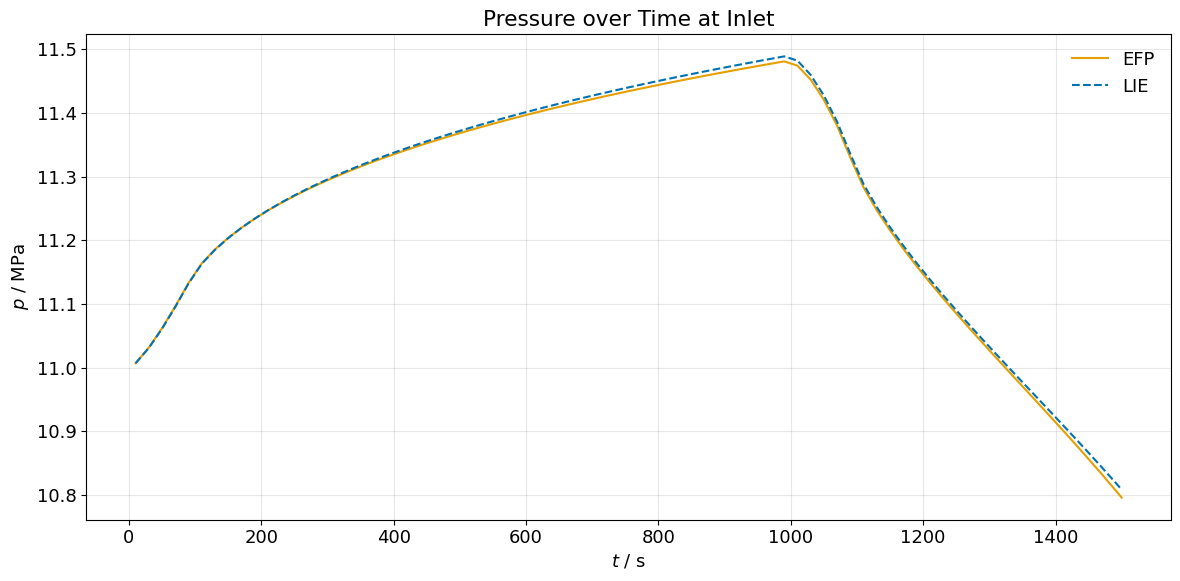

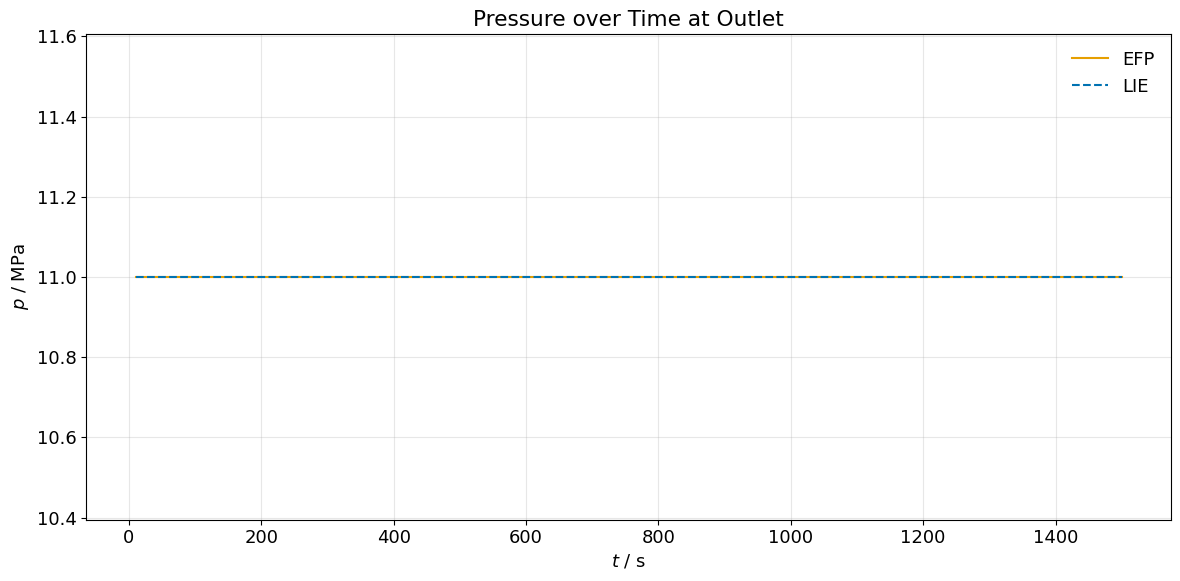

In [17]:
lie_points = (
    results_lie_in["pressure_interpolated"]["pt0"],
    results_lie_out["pressure_interpolated"]["pt1"],
)
efp_points = (
    results_efp_in["pressure_interpolated"]["pt0"],
    results_efp_out["pressure_interpolated"]["pt1"],
)
Title = ("Pressure over Time at Inlet", "Pressure over Time at Outlet")
Figname = ("Pressure_over_time_p0.png", "Pressure_over_time_p25.png")

for efp_points_bot, lie_points_bot, title, figname in zip(
    efp_points, lie_points, Title, Figname
):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(pvd_efp.timesteps[1:], (efp_points_bot + p0_lie)[1:] / 1e6,
            color=C_EFP, label="EFP")
    ax.plot(pvd_lie.timesteps[1:], (lie_points_bot)[1:] / 1e6,
            color=C_LIE, label="LIE", ls="--")
    ax.set_xlabel("$t$ / s")
    ax.set_ylabel("$p$ / MPa")
    plt.title(title)
    ax.legend()
    plt.grid()
    fig.tight_layout()
    plt.show()

## Plot Data over Line

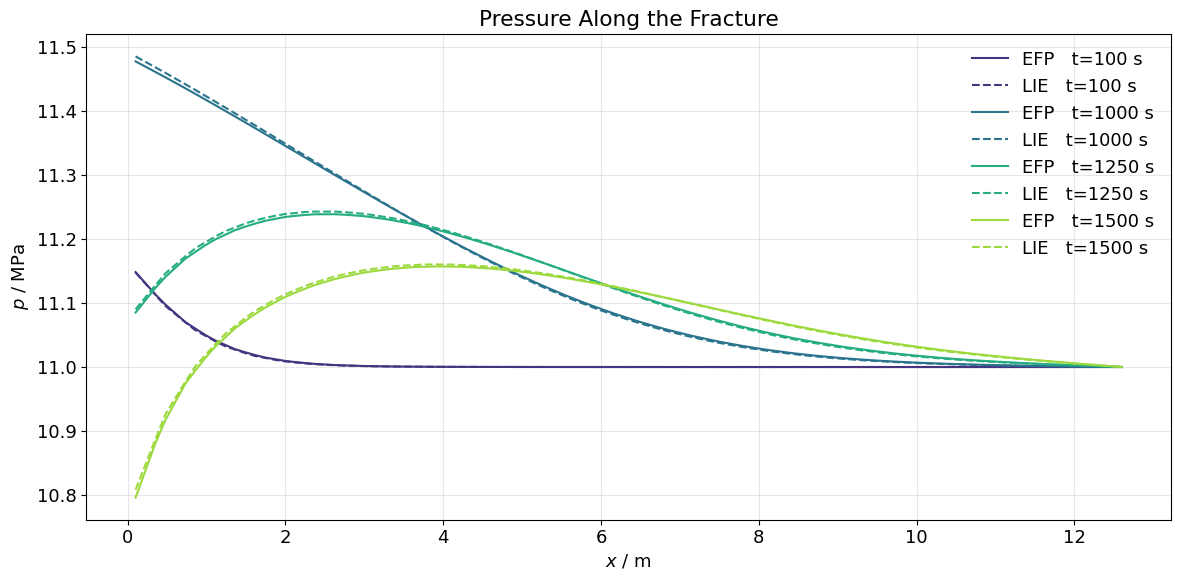

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))
# Define Axis
line_x_efp = [(i, 0.5, 0) for i in np.linspace(start=0.1, stop=12.6, num=100)]
line_x_lie = [(i, 0.5, 0) for i in np.linspace(start=0.1, stop=12.6, num=100)]
#
r_x = np.array(line_x_efp)[:, 0]
# Timestep
timesteps = [100, 1000, 1250, 1500]
# One viridis color per output time; EFP solid, LIE dashed.
time_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(timesteps)))

for color, t in zip(time_colors, timesteps):
    results_efp_line = pvd_efp.read_set_data(
        t, "pressure_interpolated", pointsetarray=line_x_efp
    )
    ax.plot(r_x, (results_efp_line + p0_lie) / 1e6, color=color,
            label="EFP   t=%i s" % t, ls="-")
    results_lie_line = pvd_lie.read_set_data(
        t, "pressure_interpolated", pointsetarray=line_x_lie
    )
    ax.plot(r_x, results_lie_line / 1e6, color=color,
            label="LIE   t=%i s" % t, ls="--")

plt.title("Pressure Along the Fracture")
ax.set_xlabel("$x$ / m")
ax.set_ylabel("$p$ / MPa")
ax.legend(loc="best")
plt.grid()
fig.tight_layout()
plt.show()

## Field Visualization

Contour plots of the full pressure and displacement fields (via `ot.MeshSeries`),
comparing the LIE and EFP solutions at the end of the injection phase, and the
evolution of the hydraulic aperture along the fracture (LIE).

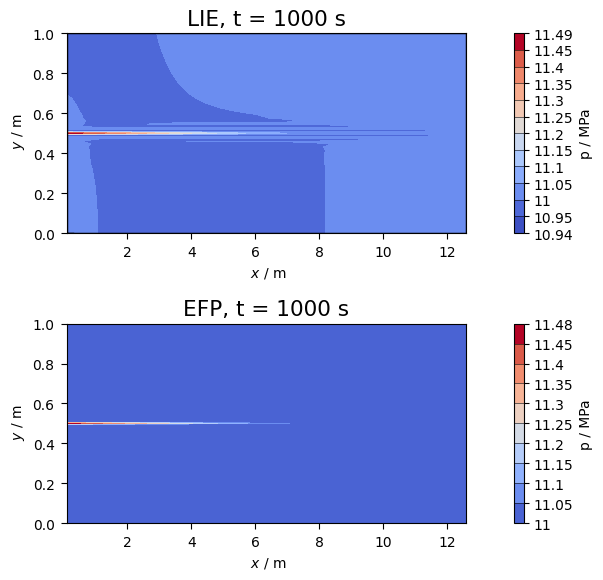

In [19]:
p_var = ot.variables.Scalar(
    data_name="pressure_interpolated", output_name="p",
    data_unit="Pa", output_unit="MPa",
)
u_var = ot.variables.Vector(
    data_name="displacement", output_name="u",
    data_unit="m", output_unit="um",
)

ms_lie = ot.MeshSeries("./SingleFractureMedium/LIE/_out_LIE/single_fracture_LIE.pvd")
ms_efp = ot.MeshSeries("./SingleFractureMedium/EFP/_out_EFP/single_fracture_EFP.pvd")

t_plot = 1000.0  # s, end of the injection phase
mesh_lie = ms_lie.mesh(ms_lie.closest_timestep(t_plot))
# drop the 1D fracture elements for the 2D contour plot
mesh_lie_2d = mesh_lie.extract_cells(mesh_lie.celltypes == 23)
mesh_efp = ms_efp.mesh(ms_efp.closest_timestep(t_plot)).copy()
# EFP is computed with relative pressures: shift by p0 for comparison
mesh_efp["pressure_interpolated"] = mesh_efp["pressure_interpolated"] + p0_lie

fig, axs = plt.subplots(2, 1, figsize=(10, 6))
ot.plot.contourf(mesh_lie_2d, p_var, fig=fig, ax=axs[0], fontsize=10)
ot.plot.contourf(mesh_efp, p_var, fig=fig, ax=axs[1], fontsize=10)
axs[0].set_title("LIE, t = %.0f s" % t_plot)
axs[1].set_title("EFP, t = %.0f s" % t_plot)
fig.tight_layout()

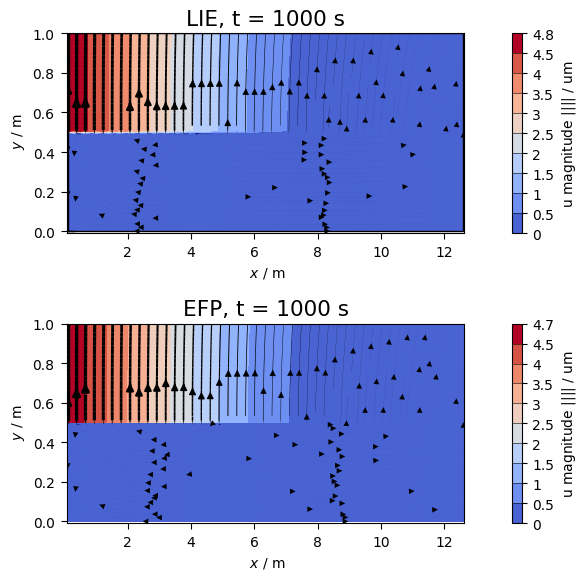

In [20]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6))
ot.plot.contourf(mesh_lie_2d, u_var, fig=fig, ax=axs[0], fontsize=10)
ot.plot.contourf(mesh_efp, u_var, fig=fig, ax=axs[1], fontsize=10)
axs[0].set_title("LIE, t = %.0f s" % t_plot)
axs[1].set_title("EFP, t = %.0f s" % t_plot)
fig.tight_layout()

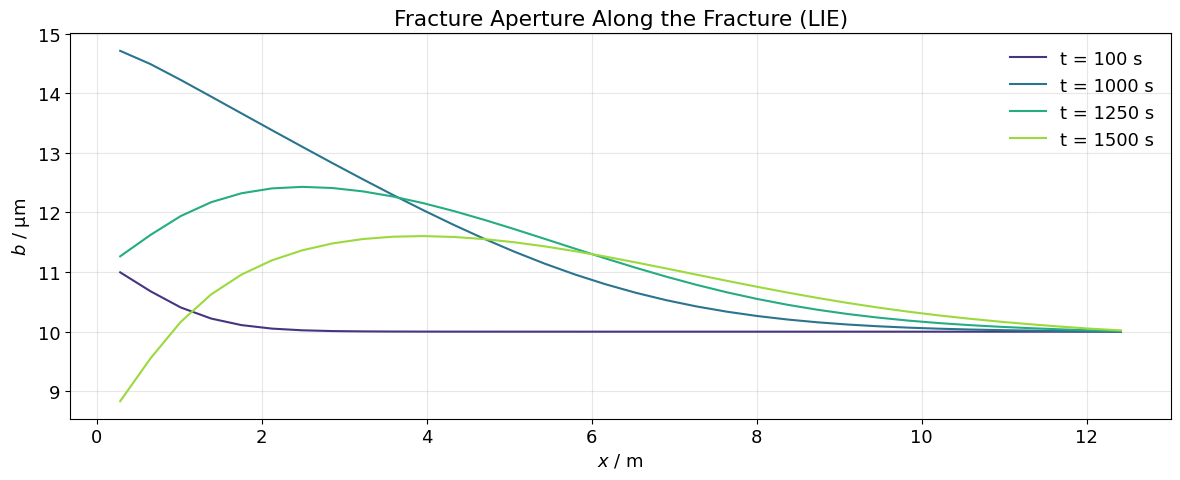

In [21]:
# Hydraulic aperture along the fracture over time (LIE only)
fig, ax = plt.subplots(figsize=(12, 5))
timesteps = [100, 1000, 1250, 1500]
# One viridis color per output time, as in the pressure-profile plots.
time_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(timesteps)))
for color, t in zip(time_colors, timesteps):
    mesh = ms_lie.mesh(ms_lie.closest_timestep(t))
    frac = mesh.extract_cells(mesh.cell_data["MaterialIDs"] == 0)
    centers = frac.cell_centers()
    aperture = centers.cell_data["fracture_aperture_avg"]
    order = np.argsort(centers.points[:, 0])
    ax.plot(centers.points[order, 0], aperture[order] * 1e6,
            color=color, label="t = %i s" % t)
ax.set_xlabel("$x$ / m")
ax.set_ylabel("$b$ / \u00b5m")
plt.title("Fracture Aperture Along the Fracture (LIE)")
ax.legend()
plt.grid()
fig.tight_layout()

## Analytical Verification (Single Fracture)

For a nearly impermeable matrix ($k_\text{M} = 10^{-21}\,$m$^2$) the injected fluid stays
inside the fracture, and the problem reduces to one-dimensional pressure diffusion along
it. Mass balance per unit fracture area with cubic-law transmissivity and a
pressure-dependent aperture reads

$$
\beta(b)\,\frac{\partial p}{\partial t}
   = \frac{\partial}{\partial x}\!\left(\frac{b^3}{12\,\mu}\,\frac{\partial p}{\partial x}\right),
\qquad b = b_0 + \frac{p-p_0}{K_\text{n}},
\qquad \beta = b\,S_\text{f} + \frac{1}{K_\text{n}},
$$

where the joint compliance $1/K_\text{n}$ dominates the storage term. With the constant
injection rate $Q$ at $x=0$ and $p=p_0$ far away, two reference solutions follow:

- **Linearized analytical solution** ($b \approx b_0$, valid for early times / far field):
  constant-flux injection into a semi-infinite medium (Carslaw & Jaeger),
  $$
  \Delta p(x,t) = \frac{Q}{T_0}\,\sqrt{4 D_0 t}\;
  \operatorname{ierfc}\!\left(\frac{x}{2\sqrt{D_0 t}}\right),
  \qquad T_0=\frac{b_0^3}{12\mu},\qquad D_0=\frac{T_0}{\beta_0}.
  $$
- **Semi-analytical 1D reference**: the full nonlinear equation above, integrated with a
  small finite-difference scheme. During injection the inlet aperture grows from
  $10$ to $\approx 15\,\mu$m, raising the transmissivity by a factor of $\approx 3$ —
  an effect the linearized solution cannot capture.

Note that `curve_q_in` ramps the injection rate linearly from zero to $Q$ over the
first $100\,$s. The 1D reference uses the same $Q(t)$ directly; for the linearized
solution the ramp is handled by Duhamel superposition of the constant-flux solution,
$$
\Delta p(0,t) = \frac{2\,A}{3\,t_\text{r}}\left[t^{3/2}-\max(t-t_\text{r},0)^{3/2}\right],
\qquad A = \frac{Q}{T_0}\sqrt{\frac{4 D_0}{\pi}}.
$$
Both are compared with the LIE and EFP results during the injection phase
($t \le 1000\,$s). The remaining deviation of a few percent stems from the elastic
compliance of the 2D matrix, which the 1D fracture model does not represent.

In [22]:
from scipy.special import erfc

# Fracture-flow parameters (identical to the parametrisation above)
L_frac = 12.5                      # fracture length [m]
t_ramp = 100.0                     # injection ramp time from curve_q_in [s]
Q_ana = q_f                        # injection rate per unit width [m^2/s]
T0 = b**3 / (12 * mu_f)            # initial transmissivity [m^3/(Pa s)]
beta0 = b * S_f + 1.0 / Kn         # storage per fracture area [m/Pa]
D0 = T0 / beta0                    # hydraulic diffusivity [m^2/s]
print(f"T0 = {T0:.3e}, beta0 = {beta0:.3e}, D0 = {D0:.3e} m^2/s")


def dp_linearized(x, t):
    """Constant-flux injection into a semi-infinite fracture with b = b0."""
    z = x / (2 * np.sqrt(D0 * t))
    ierfc = np.exp(-z**2) / np.sqrt(np.pi) - z * erfc(z)
    return (Q_ana / T0) * np.sqrt(4 * D0 * t) * ierfc


def dp_linearized_inlet_ramped(t):
    """Inlet pressure for the ramped injection rate (Duhamel superposition)."""
    t = np.asarray(t, dtype=float)
    A = (Q_ana / T0) * np.sqrt(4 * D0 / np.pi)
    return 2 * A / (3 * t_ramp) * (t**1.5 - np.maximum(t - t_ramp, 0.0)**1.5)


def solve_reference(t_end, nx=251, dt=0.02):
    """Nonlinear 1D fracture flow (cubic law + joint compliance), explicit FD."""
    x = np.linspace(0, L_frac, nx)
    dx = x[1] - x[0]
    p = np.full(nx, float(p0_lie))
    t_hist, p_in_hist = [], []
    for step in range(int(round(t_end / dt))):
        q_t = Q_ana * min((step + 0.5) * dt / t_ramp, 1.0)  # ramped rate
        b_cur = b + (p - p0_lie) / Kn
        T_cur = b_cur**3 / (12 * mu_f)
        T_face = 0.5 * (T_cur[:-1] + T_cur[1:])
        flux = T_face * np.diff(p) / dx
        beta_cur = b_cur * S_f + 1.0 / Kn
        dpdt = np.zeros_like(p)
        dpdt[1:-1] = (flux[1:] - flux[:-1]) / dx / beta_cur[1:-1]
        dpdt[0] = (flux[0] + q_t) / (dx / 2) / beta_cur[0]
        p += dt * dpdt
        p[-1] = p0_lie
        if step % 50 == 0:
            t_hist.append((step + 1) * dt)
            p_in_hist.append(p[0])
    return x, p, np.array(t_hist), np.array(p_in_hist)

T0 = 8.333e-14, beta0 = 1.000e-11, D0 = 8.333e-03 m^2/s


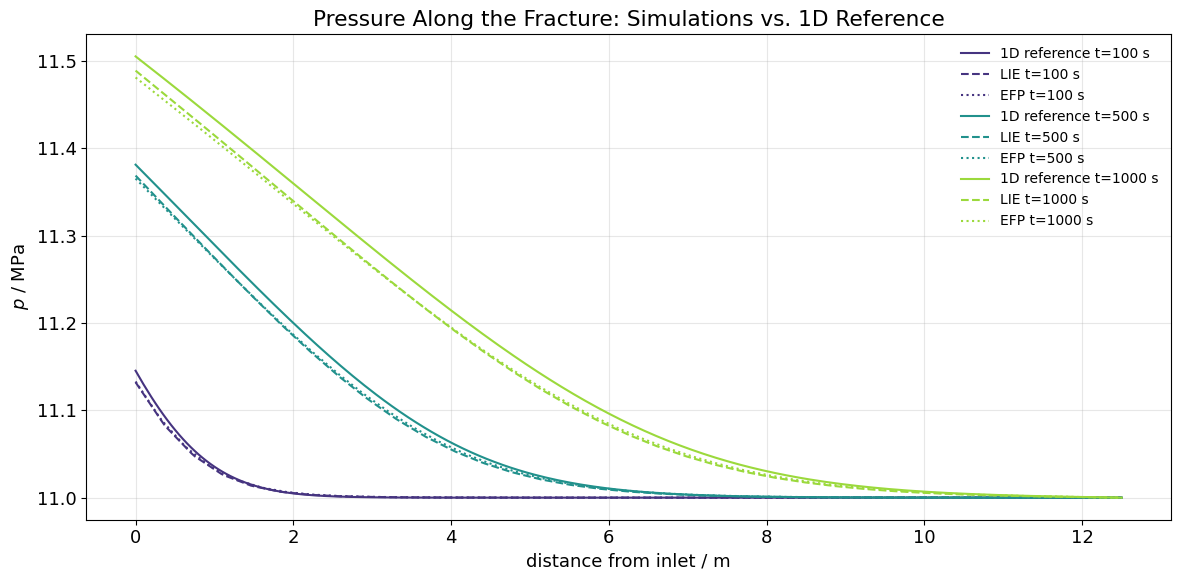

In [23]:
import pyvista as pv

x_s = np.linspace(0.1, 12.6, 300)
line = pv.PolyData(np.column_stack([x_s, np.full_like(x_s, 0.5), np.zeros_like(x_s)]))

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, 3))
for color, t in zip(colors, [100, 500, 1000]):
    x_ref, p_ref, _, _ = solve_reference(t)
    ax.plot(x_ref, p_ref / 1e6, color=color, ls="-", label="1D reference t=%i s" % t)
    sampled = line.sample(ms_lie.mesh(ms_lie.closest_timestep(t)))
    ax.plot(x_s - 0.1, sampled["pressure_interpolated"] / 1e6, color=color, ls="--",
            label="LIE t=%i s" % t)
    sampled = line.sample(ms_efp.mesh(ms_efp.closest_timestep(t)))
    ax.plot(x_s - 0.1, (sampled["pressure_interpolated"] + p0_lie) / 1e6,
            color=color, ls=":", label="EFP t=%i s" % t)

plt.title("Pressure Along the Fracture: Simulations vs. 1D Reference")
ax.set_xlabel("distance from inlet / m")
ax.set_ylabel("$p$ / MPa")
ax.legend(loc="best", fontsize=10)
plt.grid()
fig.tight_layout()
plt.show()

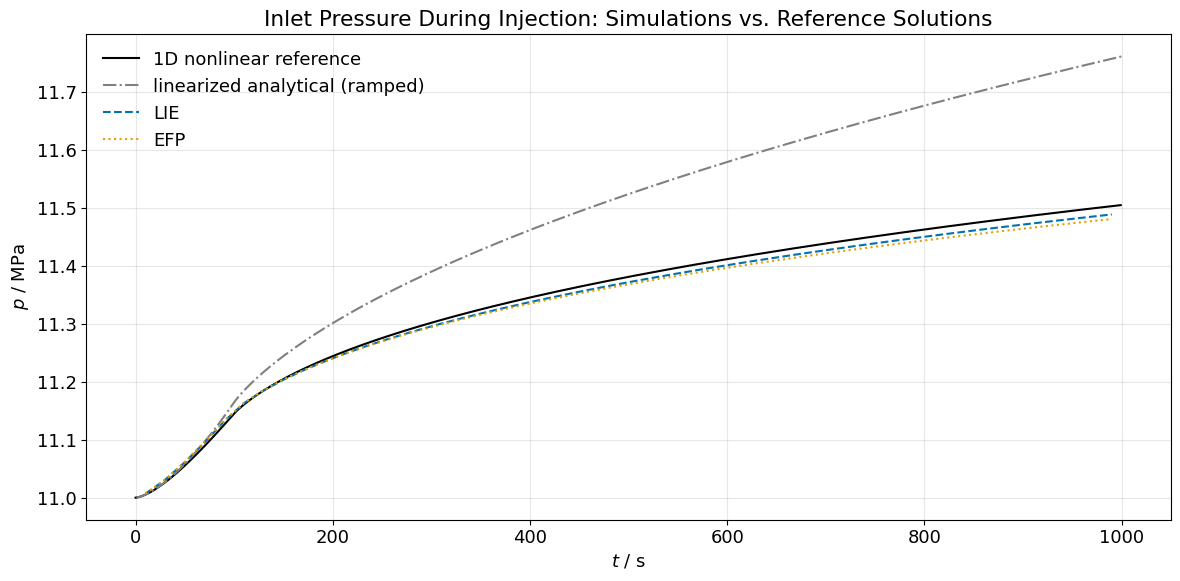

inlet dp at t=1000 s: 1D reference 5.051e+05 Pa, LIE 4.890e+05 Pa (deviation 3.3 %)


In [24]:
x_ref, p_ref, t_hist, p_in_hist = solve_reference(1000)
t_lin = np.linspace(1, 1000, 300)

t_lie = np.asarray(pvd_lie.timesteps)
m_lie_mask = (t_lie > 0) & (t_lie <= 1000)
p_lie_in = results_lie_in["pressure_interpolated"]["pt0"]
t_efp = np.asarray(pvd_efp.timesteps)
m_efp_mask = (t_efp > 0) & (t_efp <= 1000)
p_efp_in = results_efp_in["pressure_interpolated"]["pt0"] + p0_lie

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t_hist, p_in_hist / 1e6, "-", color="black",
        label="1D nonlinear reference")
ax.plot(t_lin, (p0_lie + dp_linearized_inlet_ramped(t_lin)) / 1e6, "-.",
        color="0.5", label="linearized analytical (ramped)")
ax.plot(t_lie[m_lie_mask], p_lie_in[m_lie_mask] / 1e6, "--", color=C_LIE,
        label="LIE")
ax.plot(t_efp[m_efp_mask], p_efp_in[m_efp_mask] / 1e6, ":", color=C_EFP,
        label="EFP")
plt.title("Inlet Pressure During Injection: Simulations vs. Reference Solutions")
ax.set_xlabel("$t$ / s")
ax.set_ylabel("$p$ / MPa")
ax.legend()
plt.grid()
fig.tight_layout()
plt.show()

dp_ref = p_in_hist[-1] - p0_lie
dp_lie = np.interp(t_hist[-1], t_lie[m_lie_mask], p_lie_in[m_lie_mask]) - p0_lie
print("inlet dp at t=1000 s: 1D reference %.3e Pa, LIE %.3e Pa "
      "(deviation %.1f %%)" % (dp_ref, dp_lie, 100 * abs(dp_ref - dp_lie) / dp_lie))

# Porous Medium with Two Fractures

In this section, the previous benchmark is extended to a double-fracture porous
medium with the same material properties, initial conditions, and boundary
conditions. Only the EFP model is considered here: official OpenGeoSys supports
a single displacement jump in `HYDRO_MECHANICS_WITH_LIE`, so there is no LIE
variant for two fractures.

## Porous Medium with Two Fractures Using EFP Model

In [25]:
out_dir_EFP_DF = Path(
    os.environ.get("OGS_TESTRUNNER_OUT_DIR", "./DoubleFractureMedium/EFP/_out_EFP")
)
if not out_dir_EFP_DF.exists():
    out_dir_EFP_DF.mkdir(parents=True)

In [26]:
model_efp_DF.run_model(
    path=PATH_OGS,
    logfile=str(out_dir_EFP_DF / "out.txt"),
    args=f"-o {out_dir_EFP_DF}",
)

 /home/mehran/.venvs/ogs312/bin/ogs -o DoubleFractureMedium/EFP/_out_EFP DoubleFractureMedium/EFP/double_fracture_EFP.prj
['/home/mehran/.venvs/ogs312/bin/ogs', '-o', 'DoubleFractureMedium/EFP/_out_EFP', 'DoubleFractureMedium/EFP/double_fracture_EFP.prj']


<Popen: returncode: 0 args: ' /home/mehran/.venvs/ogs312/bin/ogs -o DoubleFr...>

# Postprocessing

In [27]:
pvd_efp_DF = vtuIO.PVDIO(
    "./DoubleFractureMedium/EFP/_out_EFP/double_fracture_EFP.pvd", dim=2
)

## Plot Point Data over Time

In [28]:
# Monitoring Points
pt_in_bot = {"pt0": (0.1, 0.3, 0.0)}
pt_out_bot = {"pt1": (12.6, 0.3, 0.0)}
#
pt_in_top = {"pt0": (0.1, 0.7, 0.0)}
pt_out_top = {"pt1": (12.6, 0.7, 0.0)}
#
results_efp_in_bot = {}
results_efp_out_bot = {}
results_efp_in_top = {}
results_efp_out_top = {}

In [29]:
# helper
def read_p(reader, pts):
    files = reader.vtufilenames
    reader.vtufilenames = tqdm(
        files, total=len(files), desc="Reading time steps"
    )
    try:
        return reader.read_time_series(
            "pressure_interpolated",
            pts=pts,
            interpolation_method="nearest",
        )
    finally:
        reader.vtufilenames = files

pts_map = {
    "in":  {"bot": pt_in_bot,  "top": pt_in_top},
    "out": {"bot": pt_out_bot, "top": pt_out_top},
}
results_map = {
    "in":  {"bot": results_efp_in_bot,  "top": results_efp_in_top},
    "out": {"bot": results_efp_out_bot, "top": results_efp_out_top},
}

for side, levels in pts_map.items():
    for level, pts in levels.items():
        results_map[side][level]["pressure_interpolated"] = read_p(pvd_efp_DF, pts)

Reading time steps: 100%|██████████| 77/77 [00:00<00:00, 477.74it/s]


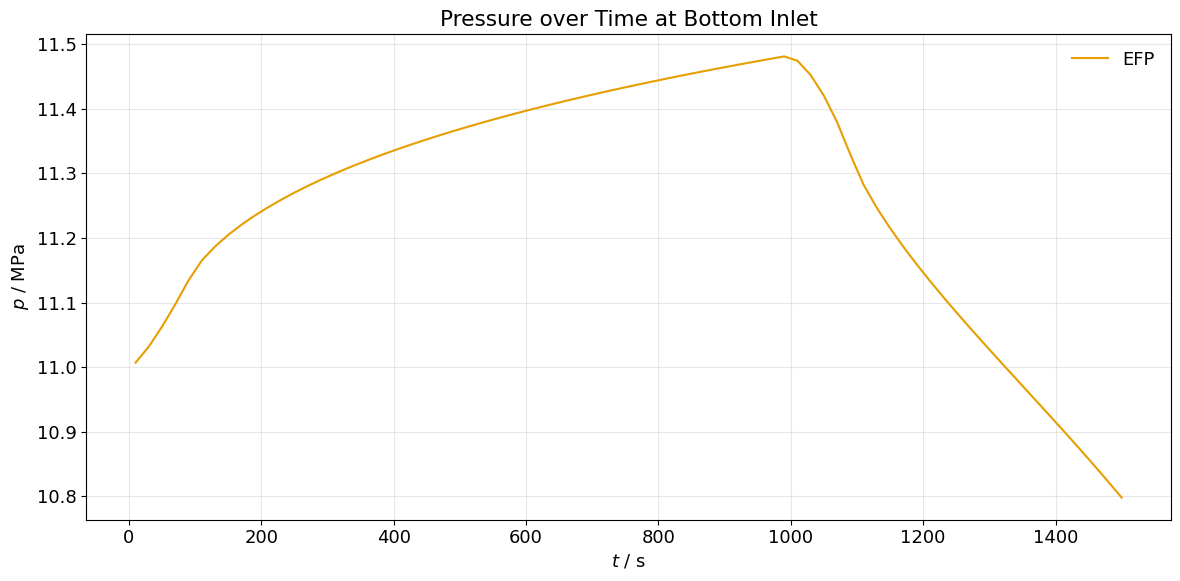

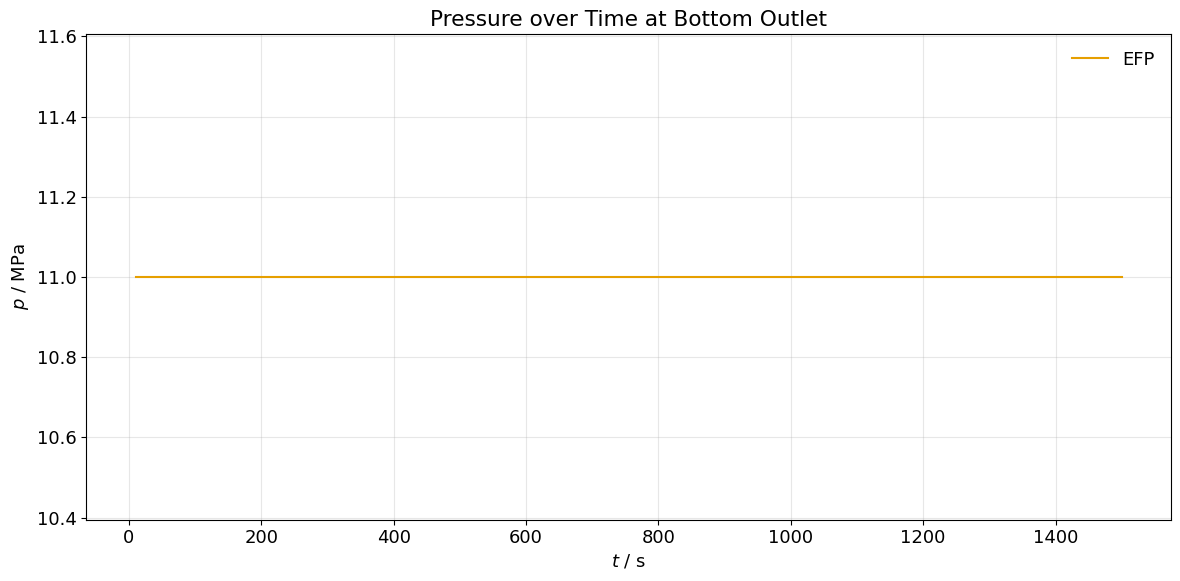

In [30]:
efp_points_bot = (
    results_efp_in_bot["pressure_interpolated"]["pt0"],
    results_efp_out_bot["pressure_interpolated"]["pt1"],
)
Title = ("Pressure over Time at Bottom Inlet", "Pressure over Time at Bottom Outlet")

for efp_points, title in zip(efp_points_bot, Title):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(pvd_efp_DF.timesteps[1:], (efp_points + p0_lie)[1:] / 1e6,
            color=C_EFP, label="EFP")
    ax.set_xlabel("$t$ / s")
    ax.set_ylabel("$p$ / MPa")
    plt.title(title)
    ax.legend()
    plt.grid()
    fig.tight_layout()
    plt.show()

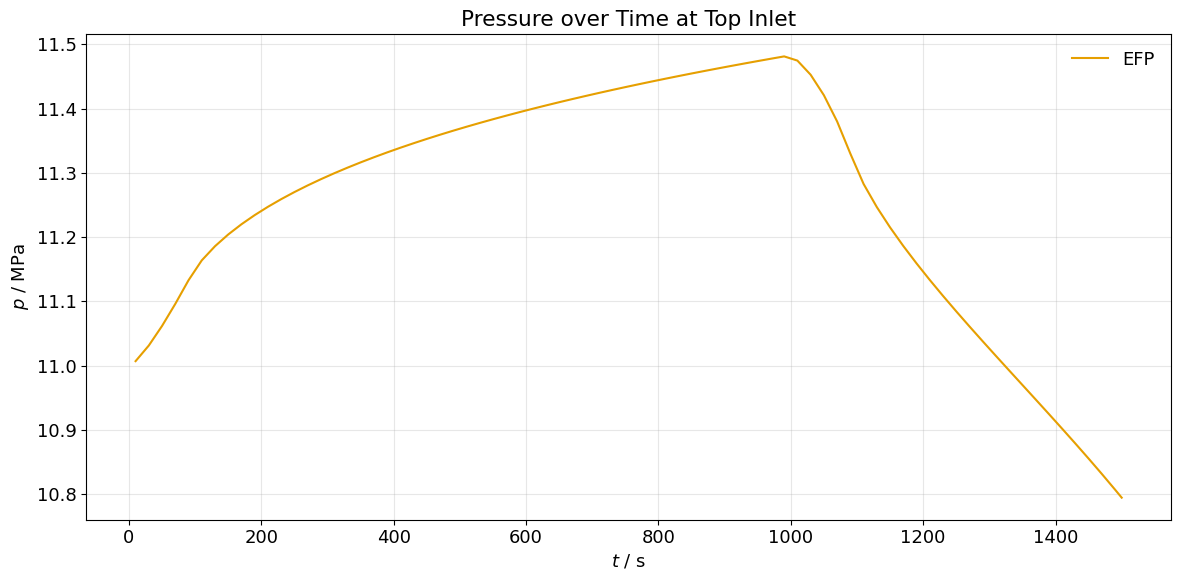

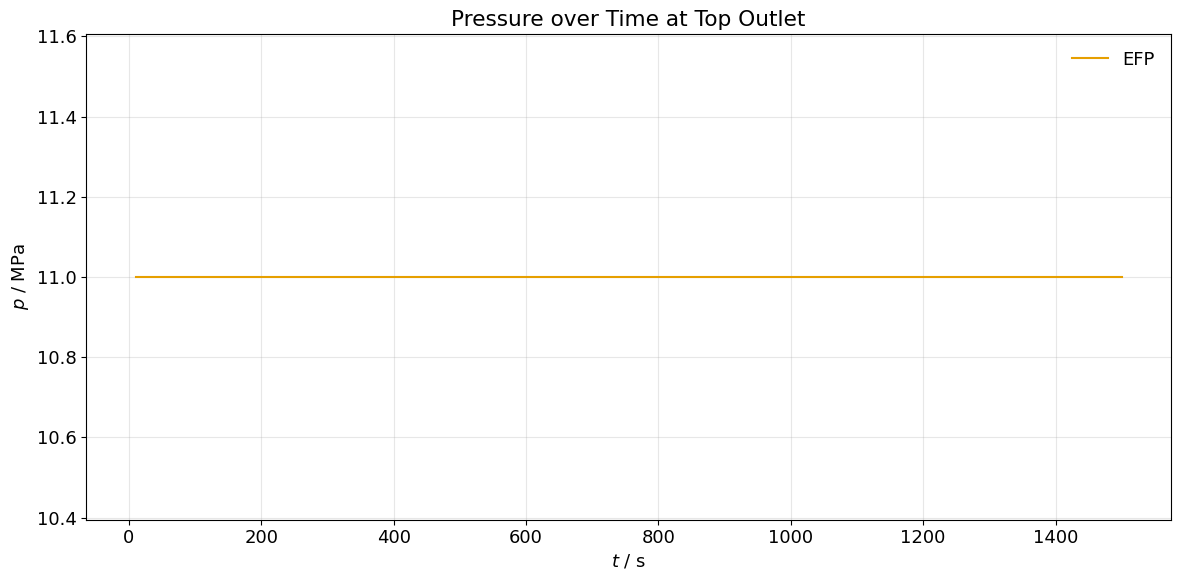

In [31]:
efp_points_top = (
    results_efp_in_top["pressure_interpolated"]["pt0"],
    results_efp_out_top["pressure_interpolated"]["pt1"],
)
Title = ("Pressure over Time at Top Inlet", "Pressure over Time at Top Outlet")

for efp_points, title in zip(efp_points_top, Title):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(pvd_efp_DF.timesteps[1:], (efp_points + p0_lie)[1:] / 1e6,
            color=C_EFP, label="EFP")
    ax.set_xlabel("$t$ / s")
    ax.set_ylabel("$p$ / MPa")
    plt.title(title)
    ax.legend()
    plt.grid()
    fig.tight_layout()
    plt.show()

## Plot Data over Line

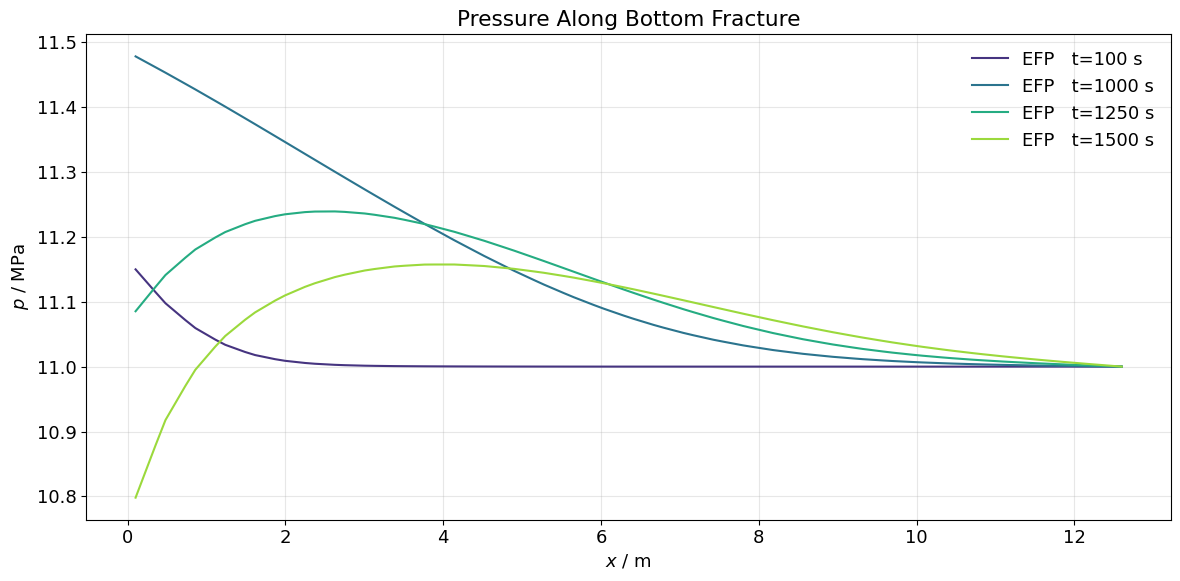

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))
# Define Axis
line_x_efp_DF = [(i, 0.3, 0) for i in np.linspace(start=0.1, stop=12.6, num=100)]
r_x = np.array(line_x_efp_DF)[:, 0]
# Timestep
timesteps = [100, 1000, 1250, 1500]
# One viridis color per output time, as in the single-fracture plots.
time_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(timesteps)))

for color, t in zip(time_colors, timesteps):
    results_efp_line = pvd_efp_DF.read_set_data(
        t, "pressure_interpolated", pointsetarray=line_x_efp_DF
    )
    ax.plot(r_x, (results_efp_line + p0_lie) / 1e6, color=color,
            label="EFP   t=%i s" % t, ls="-")

plt.title("Pressure Along Bottom Fracture")
ax.set_xlabel("$x$ / m")
ax.set_ylabel("$p$ / MPa")
ax.legend(loc="best")
plt.grid()
fig.tight_layout()
plt.show()

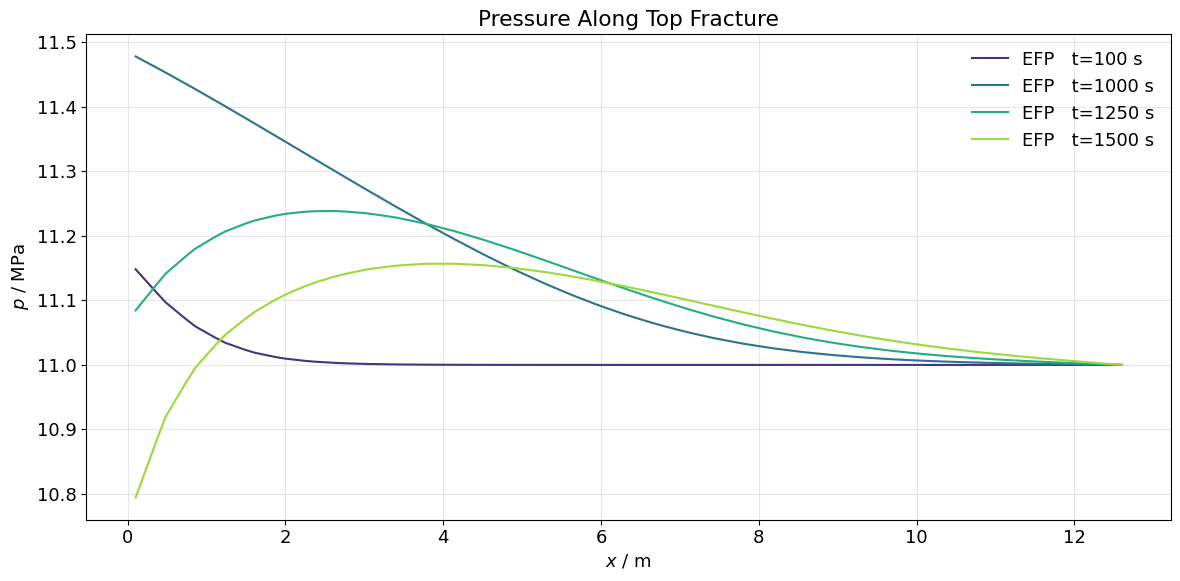

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))
# Define Axis
line_x_efp_DF = [(i, 0.7, 0) for i in np.linspace(start=0.1, stop=12.6, num=100)]
r_x = np.array(line_x_efp_DF)[:, 0]
# Timestep
timesteps = [100, 1000, 1250, 1500]
# One viridis color per output time, as in the single-fracture plots.
time_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(timesteps)))

for color, t in zip(time_colors, timesteps):
    results_efp_line = pvd_efp_DF.read_set_data(
        t, "pressure_interpolated", pointsetarray=line_x_efp_DF
    )
    ax.plot(r_x, (results_efp_line + p0_lie) / 1e6, color=color,
            label="EFP   t=%i s" % t, ls="-")

plt.title("Pressure Along Top Fracture")
ax.set_xlabel("$x$ / m")
ax.set_ylabel("$p$ / MPa")
ax.legend(loc="best")
plt.grid()
fig.tight_layout()
plt.show()

## Field Visualization (Double Fracture)

Pressure field of the double-fracture EFP model at the end of the injection
phase.

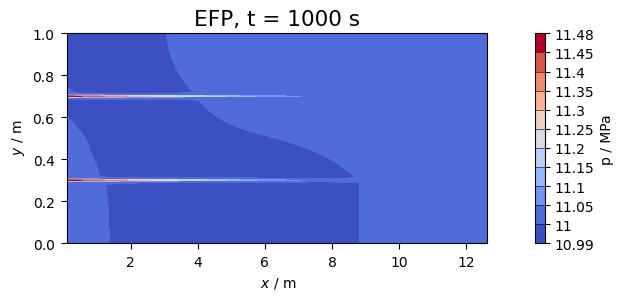

In [34]:
ms_efp_DF = ot.MeshSeries("./DoubleFractureMedium/EFP/_out_EFP/double_fracture_EFP.pvd")

mesh_efp_DF = ms_efp_DF.mesh(ms_efp_DF.closest_timestep(t_plot)).copy()
mesh_efp_DF["pressure_interpolated"] = mesh_efp_DF["pressure_interpolated"] + p0_lie

fig, ax = plt.subplots(figsize=(10, 3.2))
ot.plot.contourf(mesh_efp_DF, p_var, fig=fig, ax=ax, fontsize=10)
ax.set_title("EFP, t = %.0f s" % t_plot)
fig.tight_layout()

## References

[1] Linus Walter, 2021. Hydromechanisch gekoppelte Prozesse in störungsgebundenen Tiefengrundwasserleitern -- Erstellung eines 3D Reservoirmodells in OpenGeoSys zur Auswertung von Kluftdeformationsprozessen während Bohrlochtests beim Tiefengeothermieprojekt Geretsried. Chair for Soil Mechanics and Foundation Engineering, Geotechnical Institute, TU Bergakademie Freiberg, Germany.

[2] Zill, F., Lüdeling, C., Kolditz, O. and Nagel, T., 2021. Hydro-mechanical continuum modelling of fluid percolation through rock salt. International Journal of Rock Mechanics and Mining Sciences, 147, p.104879.

[3] Watanabe, N., Wang, W., Taron, J., Görke, U.J. and Kolditz, O., 2012. Lower‐dimensional interface elements with local enrichment: application to coupled hydro‐mechanical problems in discretely fractured porous media. International Journal for Numerical Methods in Engineering, 90(8), pp.1010-1034.

[4] https://www.opengeosys.org/docs/benchmarks/hydro-mechanics/lie-hm-linear-single-fracture/LIE_HM.pdf

[5] Cacace, M., Blöcher, G., Watanabe, N., Moeck, I., Börsing, N., Scheck-Wenderoth, M., Kolditz, O. and Huenges, E., 2013. Modelling of fractured carbonate reservoirs: outline of a novel technique via a case study from the Molasse Basin, southern Bavaria, Germany. Environmental earth sciences, 70(8), pp.3585-3602.

[6] Olivella, S. and Alonso, E.E., 2008. Gas flow through clay barriers. Géotechnique, 58(3), pp.157-176.

[7] Gerrard, C. M. (1982). Elastic models of rock masses having one, two and three sets of joints. International Journal of Rock Mechanics and Mining Sciences And, 19(1), 15–23. https://doi.org/10.1016/0148-9062(82)90706-9

[8] Leibniz Institute for Applied Geophysics (LIAG). Dolomitkluft: geothermal development and analysis of a fracture-dominated dolomitic aquifer at Geretsried. https://www.liag-institut.de/en/research/projects/third-party-funded-projects/dolomitkluft.html